# Computing for Economists: Parallelization, Cluster Computing, and Job Schedulers


In this module's exercise you will run a Monte Carlo simulation on a
computing cluster using Slurm.


### The simulation

We study the finite-sample behaviour of the just-identified 2SLS estimator when the instrument is weak. For $i = 1, \dots, n$:

$$
z_i \sim N(0,1), \qquad
\begin{pmatrix} u_i \\ v_i \end{pmatrix} \sim
N\!\left(0, \begin{pmatrix} 1 & \rho \\ \rho & 1\end{pmatrix}\right),
$$

$$
x_i = \pi z_i + v_i \qquad \text{(first stage)}, \qquad
y_i = \beta x_i + u_i \qquad \text{(structural equation)}.
$$

We fix $\beta = 1$ and $\rho = 0.5$. Since $\rho \neq 0$, $x$ is endogenous and OLS
is inconsistent, with $\operatorname{plim} \hat\beta_{OLS} = \beta + \rho/(\pi^2+1)$.
The 2SLS estimator using $z$ as an instrument,

$$
\hat\beta_{2SLS} = \frac{z'y}{z'x},
$$

is consistent for any $\pi \neq 0$. However, consistency is an asymptotic property.
What we will study here is how the estimator behaves in finite samples as the instrument becomes weaker, which
is governed by the concentration parameter $\mu^2 = n\pi^2$.

The experiment is a grid over $\pi \in \{0.02, 0.05, 0.10, 0.25, 0.50, 1.00\}$ and
$n \in \{500, 2000, 8000, 32000\}$ — 24 cells, each requiring many thousands of
independent replications. This is an embarrassingly parallel problem: cells do
not talk to each other, and replications within a cell do not talk to each other, so this is a good exercise to parallelize with a scheduler.




### How to access the shared computing cluster we'll use today

Everything today will happen on **HUIT Open OnDemand**, a web portal in front of a real
computing cluster. You don't have to install anything or use SSH. You just have to log in with
your HarvardKey and get a browser interface to the cluster.

This is probably going to be the first time any of you use this specific instance (it was for us), so we don't want you to spend a lot of time in figuring out how this specific portal works. We want to go quickly to the interaction with the scheduler. Therefore, please just follow the instructions below to get you started in the HUIT Open OnDemand platform.

In this platform, you will be able to access a terminal. The **login node** is where your terminal lands. It is shared with everyone and it is for editing files and submitting jobs, not for computing. You will access the cluster's **compute nodes** when they are handed to you by the Slurm scheduler, one job at a time.

Finally, this cluster runs on AWS (which stands for Amazon Web Services, an online platform that rents computer power and storage space) and its compute nodes are elastic, which means that they boot (turn on) when demand appears and they shut down when idle. The boot time will show up in your waiting times.

The official HUIT documentation for the HUIT Open OnDemand platform is at
<https://harvard-atg.github.io/huit-ondemand-user-docs/>. Ideally you won't have to look at it, but we put it here just in case. There is a
[troubleshooting page](https://harvard-atg.github.io/huit-ondemand-user-docs/troubleshooting/), if something misbehaves.

**On time management.** Some cells submit jobs that take several minutes. Read
ahead while they run rather than watching the clock tick :)


## Part 0: Set up

**0.1 — Log in and open a terminal.**

1. Go to <https://stage.ood.huit.harvard.edu/> and log in with your HarvardKey.
2. You land on the **dashboard**. The two menus you will need are *Files* and
   *Clusters*.
3. Go to *Clusters* &rarr; *pc-stage Shell Access*. A terminal opens in a new browser
   tab. If it asks you for a password, something is misconfigured, so try again and if it persists, let us know.

That terminal runs on a **login node**, and it is where you will submit jobs and
check on them.

Check where you landed, and that the course folder (named 170063) is linked in your home directory:

```bash
hostname        # this tells you the name of the machine you are on
ls ~/170063     # this lists the files in the course folder (which is named 170063)
```

You should see the course folder's contents. That link is created for you at login
because you are enrolled in the course.

**The workflow for today** You read and run
this notebook **on your own laptop**. That is where you write the job scripts, and where
you analyse the results at the end. The cluster you drive entirely from the OnDemand
terminal you have just opened: you upload the scripts this notebook generates into
`~/scheduler_exercise` using the *Files* browser, submit them there with `sbatch`, and
paste Slurm's accounting output back into the notebook.

Every cell from here on carries one of two labels:

- *Run this cell here, in the notebook.* These are real code cells that you run locally (in your laptop)
- *Copy this into the OnDemand terminal.* These are **not** code
  cells, just formatted text, so that *Run All* in the Jupyter notebook never tries to execute them. What you must do is select
  the block, copy it, and paste it into the terminal tab.


**0.2 — Activate the course software.** The course's software is managed with
**Spack**--an open-source package manager designed primarily for High-Performance Computing (HPC)--, and it is not on your `PATH` when you log in. Copy the block below into the OnDemand terminal to turn it on:

```bash
. ~/170063/spack/share/spack/setup-env.sh
spack env activate econ2003
```

Note the leading dot on the first line. `.` is shorthand for `source`: it runs
the script in your current shell rather than in a subshell, which is the only way it
can change your `PATH`. Don't omit it.

Check that it worked by copying the block below into the OnDemand terminal. These should run and show you a pyhton and uv executable, and a version of uv.

```bash
which python
which uv
uv --version
```

Before we let you go, just three things worth remembering about the scope of the environment you just activated:

1. **It lasts for the current shell only.** If you open a new terminal, you must run both
   lines again.
2. **It does not automatically apply to your jobs.** A batch job runs in a fresh
   shell on a different machine. That is why every `.sbatch` script in this exercise
   repeats these two lines.
3. **Do not put them in your `~/.bashrc`** A `.bashrc` that
   errors is the most common cause of interactive apps failing to launch on this
   platform. Putting the lines in each
   job script is both safer and more reproducible: the script then documents its own
   environment, and still works if someone else runs it.


**0.3 — Create the project.** Everything you will do today should live in one folder in your home
directory, not in the shared course folder, which you should treat as read-only. Copy the block below into the OnDemand terminal to create the folder where you will be working today and set up your virtual environment there:

```bash
mkdir -p ~/scheduler_exercise && cd ~/scheduler_exercise    # create a folder for the exercise and move into it
uv init .                                                   # initialize the folder as a uv project
uv add numpy pandas joblib matplotlib                       # add the packages we will use in this exercise to the project environment
```

`uv` is the Python dependency manager used on this platform. It writes a
`pyproject.toml` and a `uv.lock` and creates a `.venv` in the folder. From now on we
launch Python as **`uv run python ...`**, which uses that environment without any
`activate` step. The `uv.lock` file is what makes your run reproducible by
someone else.

One thing worth flagging (just in case): The folder you just created is on the cluster. This notebook is running on your own computer (locally), and that is where it writes the `.py` and `.sbatch` files you will be uploading to the server.

Run the cell below in your computer to create a folder called "output", which is where we will be saving the scripts that will land on your side:

In [3]:
import os

# Everything this notebook generates - the .py scripts, the .sbatch files, the
# parameter grid - goes into an "output" folder next to the notebook.
os.makedirs("output", exist_ok=True)

print("Generated files will go in:", os.path.abspath("output"))

Generated files will go in: /Users/smedinap/Library/CloudStorage/OneDrive-Personal/Documents/Harvard-PhD/Teaching/1-Econ2003-Computing-Fall2026/scheduler_exercise/output


**0.4 — Reference sheet.** First, the three lines that go at the top of every job
script you write today:

```bash
. ~/170063/spack/share/spack/setup-env.sh
spack env activate econ2003
export OMP_NUM_THREADS=1
```

The first two are the activation from 0.2, which a job does not inherit and so has to
repeat.

The third line (export OMP_NUM_THREADS=1) pins down the linear-algebra threading. In a nutshell, when we set the option equal to 1, it prevents the computer from automatically parallelizing. Some functions parallelize automatically and we want to shut down that behavior for illustration purposes in this module. We will explore what happens when we turn it off later.

We have added some reminder of the Slurm basics below, in case you need a refresher or a quick source while solving the exercise.

**Paths**

| What | Where |
|---|---|
| your home directory | `~` |
| course shared folder (treat as read-only) | `~/170063` |
| your project for this exercise | `~/scheduler_exercise` |
| job logs | `~/scheduler_exercise/logs/` |

**Slurm commands**

| Command | What it does |
|---|---|
| `sbatch script.sbatch` | submit a job; prints the job id |
| `sbatch --parsable script.sbatch` | submit, printing *only* the id (handy in scripts) |
| `squeue -u $(whoami)` | your queued and running jobs |
| `squeue -j <jobid>` | one job, or all tasks of an array job |
| `scancel <jobid>` | cancel a job |
| `scancel -u $(whoami)` | cancel everything of yours |
| `sacct -j <jobid> --format=JobID,State,Submit,Start,End,Elapsed,AllocCPUS,ReqMem,MaxRSS` | accounting for a finished job |
| `sinfo` | partitions and node states |
| `scontrol show job <jobid>` | everything Slurm knows about a job |

**Job states you will see:** `PD` pending (waiting for resources) · `CF`
configuring (a node is booting — this cluster is elastic) · `R` running ·
`CD` completed · `F` failed · `TO` timeout · `OOM` out of memory · `CA` cancelled.

**Useful environment variables inside a job:** `$SLURM_JOB_ID`,
`$SLURM_CPUS_PER_TASK`, `$SLURM_ARRAY_TASK_ID`, `$SLURM_ARRAY_JOB_ID`,
`$SLURM_SUBMIT_DIR`.

**Filename patterns in `--output` / `--error`:** `%x` job name · `%j` job id ·
`%A` array job id · `%a` array task id.


**0.5 — Helper functions.** Let's execute the code below to create some helper functions for this exercise. Read them once so
you know what they do, then use them.

In [4]:
import glob
import io
import os
import sys

import numpy as np
import pandas as pd

CODE = "code"      # the scripts we gave you; you will not need to change most of them
OUT = "output"     # stuff generated by this notebook and that you will upload to the server

os.makedirs(OUT, exist_ok=True)

# Put `code/` on the import path so we can call the provided scripts as ordinary
# Python instead of shelling out.
if CODE not in sys.path:
    sys.path.insert(0, CODE)

SACCT_FMT = ("JobID,JobName,State,Submit,Start,End,Elapsed,"
             "AllocCPUS,ReqMem,MaxRSS,ExitCode")


def to_unix(pattern=None):
    r"""Rewrite the generated job scripts with Unix (LF) line endings.

    Jupyter's %%writefile opens files in text mode, so on Windows every newline
    is written as CRLF. Slurm refuses to run such a script:

        sbatch: error: Batch script contains DOS line breaks (\r\n)
        sbatch: error: instead of expected UNIX line breaks (\n).

    Run this after any %%writefile cell, before you upload. It reads and writes
    in binary mode so nothing gets translated, and it is harmless on macOS and
    Linux, where the files are already LF.
    """
    pattern = pattern or os.path.join(OUT, "*.sbatch")
    paths = sorted(glob.glob(pattern))
    converted = []
    for path in paths:
        with open(path, "rb") as fh:
            raw = fh.read()
        clean = raw.replace(b"\r\n", b"\n").replace(b"\r", b"\n")
        if clean != raw:
            converted.append(os.path.basename(path))
        with open(path, "wb") as fh:
            fh.write(clean)
    print(f"{len(paths)} script(s) in {OUT}/ checked; "
          f"converted to LF: {', '.join(converted) if converted else 'none needed'}")


def _mem_to_mb(value):
    """Parse a Slurm memory figure like '184052K', '1.5G' or '2Gn' into MB."""
    if not isinstance(value, str) or not value.strip():
        return float("nan")
    text = value.strip().rstrip("nc")          # older Slurm appends n (node) or c (core)
    units = {"K": 1 / 1024, "M": 1.0, "G": 1024.0, "T": 1024.0 ** 2}
    try:
        if text and text[-1].upper() in units:
            return float(text[:-1]) * units[text[-1].upper()]
        return float(text) / (1024 * 1024)     # a bare number means bytes
    except ValueError:
        return float("nan")


def sacct_table(pasted):
    """Turn pasted `sacct --parsable2` output into a table, one row per job.

    Adds QueueSec (Start - Submit, the time spent waiting) and RunSec
    (End - Start, the time spent computing).

    Slurm reports peak memory on the job's *steps*, not on the job itself: the
    `MaxRSS` column is empty on row `8` and filled in on row `8.batch`. So we take
    the largest MaxRSS across a job's steps and attach it to the job's own row,
    then drop the step rows to keep the table readable. `MaxRSS_MB` and `ReqMem_MB`
    are numeric, so you can compare what you asked for against what you used.
    """
    if not pasted.strip():
        print("Nothing pasted yet. On the cluster, run:\n")
        print(f"    sacct -j <jobid> --parsable2 --format={SACCT_FMT}\n")
        print("then paste the whole output, header line included, between the quotes.")
        return pd.DataFrame()

    df = pd.read_csv(io.StringIO(pasted.strip()), sep="|")
    for c in ("Submit", "Start", "End"):
        if c in df:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    df["QueueSec"] = (df["Start"] - df["Submit"]).dt.total_seconds()
    df["RunSec"] = (df["End"] - df["Start"]).dt.total_seconds()

    ids = df["JobID"].astype(str)
    df["_base"] = ids.str.split(".").str[0]
    is_step = ids.str.contains(r"\.", regex=True)

    if "MaxRSS" in df:
        step_rss = (df.loc[is_step]
                      .assign(_mb=lambda d: d["MaxRSS"].map(_mem_to_mb))
                      .groupby("_base")["_mb"].max())
    else:
        step_rss = pd.Series(dtype=float)

    jobs = df.loc[~is_step].copy()
    jobs["MaxRSS_MB"] = jobs["_base"].map(step_rss).round(1)
    if "ReqMem" in jobs:
        jobs["ReqMem_MB"] = jobs["ReqMem"].map(_mem_to_mb).round(1)

    if not is_step.any():
        print("Note: no step rows (like `8.batch`) in what you pasted, so MaxRSS is\n"
              "empty. Slurm records peak memory on the step, not on the job. Paste the\n"
              "whole sacct output and MaxRSS_MB will fill in.\n")

    return jobs.drop(columns="_base").reset_index(drop=True)


**0.6 — The input code**

The point of this exercise is to get you familiar with the scheduler, so we will not
ask you to write the IV simulation. Three files come in the repo with this notebook, in the
`code/` folder next to it:

| File | What it is |
|---|---|
| `simulate_iv.py` | Runs the Monte Carlo and writes one one-row CSV per cell of the grid. Takes `--task-id` to run a single cell or `--all` to run all 24 one after another, and `--n-jobs` for how many worker processes to use. You do not need to change it. |
| `params.csv` | The grid: 24 rows, one per $(\pi, n)$ cell, each with a number of replications and its own random seed. Keeping parameters in a file rather than in the job script is a habit worth copying. It scales to grids with many varying parameters, and is better for reproducibility. |
| `aggregate_results.py` | Collects the 24 one-row CSVs into a single `summary.csv`. It takes `--expected 24` and fails if any cell is missing. |

Have a quick look at `simulate_iv.py` now, in particular the top of `main()`, just
after the arguments are parsed: it decides how many worker processes to use by reading
`SLURM_CPUS_PER_TASK` from the environment. That is the pattern we taught in the slides, and it is what keeps your code's
parallelism and your resource request from drifting apart.

**How we code the parallelization** `simulate_iv.py` has two ways of running a
cell's replications:

- `run_cell_serial` — an ordinary Python loop over the replications.
- `run_cell_parallel` — uses **`joblib.Parallel` and `delayed`**, the same construct
  from the slides. You will read it line by line in Part 3.

`run_one_row` chooses between them based on `n_jobs`:

```python
if n_jobs and n_jobs > 1:
    draws = run_cell_parallel(n, pi, reps, seed, n_jobs)
else:
    draws = run_cell_serial(n, pi, reps, seed)
```

Whatever you pass in `--n-jobs`
ends up as the `n_jobs` argument of `joblib.Parallel(n_jobs=...)`.

You do not need the IV details to do this exercise. All that matters is that one
cell of the grid is a chunk of work that takes a while, and that the 24 cells are
completely independent of one another.

**Checkpoint.** The next cell should print `Part 0 complete` with no
assertion errors.

In [7]:
import os

import pandas as pd

for f in ["code/simulate_iv.py", "code/aggregate_results.py", "code/params.csv"]:
    assert os.path.exists(f), f"missing {f} - is the code/ folder next to this notebook?"

params = pd.read_csv("code/params.csv")
assert params.shape == (24, 5), f"params.csv should be 24x5, got {params.shape}"
assert set(params.columns) == {"task_id", "pi", "n", "reps", "seed"}

# Import the simulation and run one tiny cell, to confirm it works on your machine.
# `code/` is already on sys.path, courtesy of the helper cell above.
import simulate_iv

row = params.loc[params["task_id"] == 1].iloc[0]
simulate_iv.run_one_row(row, n_jobs=1, outdir="output/smoke_test",
                        reps_override=50)

assert os.path.exists("output/smoke_test/cell_001.csv"), "the smoke test wrote nothing"
print("\nPart 0 complete")

task   1  pi=0.02  n=500     reps=50      n_jobs=1     0.00s  -> output/smoke_test/cell_001.csv

Part 0 complete


## Part 1: One job, one core


<font color = '701B1B'>**0. Conceptual**</font>

**1.1 — Old-fashioned way: running things on your laptop.** Before submitting
anything, let us see how our own computer would do.

The full grid at production settings is 24 cells $\times$ 60,000 replications. We will time a single cell at reduced
replications, and use it to predict the cost of the whole grid.

Run the code below and respond to the question:

*Run this cell here, in the notebook.* Times one cell of the grid on your own machine. Task 4 sits at the largest sample size in the grid, $n = 32{,}000$, so it is one of the most expensive cells and the useful one to measure.

In [10]:
import simulate_iv

params = pd.read_csv("code/params.csv")
row = params.loc[params["task_id"] == 4].iloc[0]      # pi = 0.02, n = 32,000

rec = simulate_iv.run_one_row(row, n_jobs=1, outdir="output/calib",
                              reps_override=500)

per_rep_at_32k = rec["elapsed_sec"] / 500
print(f"\nthat is {per_rep_at_32k:.4f} seconds per replication, at n = 32,000")

task   4  pi=0.02  n=32000   reps=500     n_jobs=1     0.20s  -> output/calib/cell_004.csv

that is 0.0004 seconds per replication, at n = 32,000


<font color = 'red'>**1. Write it yourself**</font>

Now extrapolate to the whole grid yourself. Two facts you need:

- `params` has one row per cell, each with its own `n` and `reps`.
- The cost of one replication is close to **proportional to $n$**: a replication draws
  three arrays of length $n$ and takes a few inner products of them. So a
  replication at sample size $n$ costs about `per_rep_at_32k * n / 32000`. (There is
  also a small fixed cost per replication that this ignores.)

Work out `est`, the total seconds the 24 cells would take if run one after another
on this machine.

In [11]:
est = (per_rep_at_32k * params["n"] / 32000 * params["reps"]).sum()

print(f"full grid, run serially: {est / 60:.1f} minutes")

full grid, run serially: 3.2 minutes


How long does it take to run the full grid serially? Is that something you would want to babysit in a terminal that dies when you
close the tab? This exercise was just with 24 cells. A real specification search may even be larger.

*Write your answer here:*

<font color = 'red'>**1. Write it yourself**</font>

**1.2 — Write your first batch script.** A Slurm batch script is an ordinary
bash script with a block of `#SBATCH` comments at the top. Slurm reads those lines
*before* bash runs the file, but to bash they are just comments.

Fill in the four `TODO`s below, then run the cell to write the file.

Guidance:

- `--cpus-per-task`: this run is serial, so ask for what a serial run needs.
- `--mem`: Give your best guess-timate. If it fails, try again.
- `--time`: use your Part 1.1 timing for one cell, with a margin.
- the environment: there are the two lines from 0.2.

We filled in a couple of things already in the script:

- `#SBATCH --output=logs/%x-%j.out` — `%x` is the job name, `%j` the job id.
  Slurm does not create the `logs/` directory for you, and it opens these two files
  *before* your script starts running. So `logs/` has to exist **at submission time**,
  which is why you will create it from the terminal in 1.3, before the first `sbatch`.
- `export OMP_NUM_THREADS=1` — This option is quite important! NumPy's linear
  algebra backend will spawn its own threads, using as many cores as it can see on
  the node, regardless of what you asked Slurm for. This implies that a job you believe
  is serial can actually end up using 16 cores. Setting this option to 1 ensures that everything stays in "one core" which is what we want for this part of the exercise. We come back to it in Part 3.


*Run this cell here, in the notebook.* Fill in the four `TODO`s, then run it. It writes the job script to `output/mc_one.sbatch` on your computer. Nothing is submitted yet.

In [17]:
%%writefile output/mc_one.sbatch
#!/bin/bash
#SBATCH --job-name=mc_one
#SBATCH --cpus-per-task=1
#SBATCH --mem=2G
#SBATCH --time=00:15:00
#SBATCH --output=logs/%x-%j.out
#SBATCH --error=logs/%x-%j.err

set -euo pipefail
cd "$SLURM_SUBMIT_DIR"
mkdir -p logs results

. ~/170063/spack/share/spack/setup-env.sh
spack env activate econ2003

export OMP_NUM_THREADS=1

echo "host      : $(hostname)"
echo "job id    : $SLURM_JOB_ID"
echo "cpus given: $SLURM_CPUS_PER_TASK"
echo "cores the node has     : $(nproc --all)"
echo "cores this job may use : $(python -c 'import os; print(len(os.sched_getaffinity(0)))')"

uv run python simulate_iv.py --task-id 4 --outdir results


Overwriting output/mc_one.sbatch


If you are on **Windows**, there is one more step before this script will run.
Jupyter writes files using your platform's line endings, and on Windows that means
each line ends with a carriage return plus a newline (`\r\n`) rather than just a
newline (`\n`). Slurm rejects those outright. The cell below rewrites every `.sbatch` file in `output/` with Unix line endings.
**Run it after any change to a job script, before you upload.** On macOS and Linux it
finds nothing to do, so it is safe to run either way.

*Run this cell here, in the notebook.* Converts the job scripts to Unix line endings. Re-run it whenever you edit one.

In [14]:
to_unix()

6 script(s) in output/ checked; converted to LF: none needed


<font color = '701B1B'>**0. Conceptual**</font>

**1.3 — Submit it and see what happens.**

**Upload to `~/scheduler_exercise`:** `code/simulate_iv.py`, `code/aggregate_results.py`, `code/params.csv` and `output/mc_one.sbatch`. In the OnDemand *Files* browser you can select several at once. Note they all land in the same folder on the cluster; the `code/` and `output/` split only exists on your computer.

*Copy this into the OnDemand terminal.* Then submit the job and look at the queue. `squeue` prints nothing once the job has finished.

```bash
cd ~/scheduler_exercise
mkdir -p logs results
sbatch mc_one.sbatch
squeue -u $(whoami)
```

*Copy this into the OnDemand terminal.* Once the job has finished, this prints its accounting record.

```bash
sacct -j <jobid> --parsable2 --format=JobID,JobName,State,Submit,Start,End,Elapsed,AllocCPUS,ReqMem,MaxRSS,ExitCode
```

*Run this cell here, in the notebook.* Paste that output between the triple quotes, then run it. Paste **all** of it, including the `.batch` row: Slurm records peak memory on the step rather than on the job, so `MaxRSS` only appears there.

In [20]:
SACCT_ONE = """
JobID|JobName|State|Submit|Start|End|Elapsed|AllocCPUS|ReqMem|MaxRSS|ExitCode
74|mc_one|COMPLETED|2026-08-10T16:39:16|2026-08-10T16:42:39|2026-08-10T16:45:04|00:02:25|1|2G||0:0
74.batch|batch|COMPLETED|2026-08-10T16:42:39|2026-08-10T16:42:39|2026-08-10T16:45:04|00:02:25|1||117320K|0:0
"""

rep = sacct_table(SACCT_ONE)
if len(rep):
    print(rep[["JobID", "JobName", "State", "Elapsed", "AllocCPUS",
               "ReqMem_MB", "MaxRSS_MB", "QueueSec"]].to_string(index=False))

JobID JobName     State  Elapsed  AllocCPUS  ReqMem_MB  MaxRSS_MB  QueueSec
   74  mc_one COMPLETED 00:02:25          1     2048.0      114.6     203.0


**Checkpoint.**

*Run this cell here, in the notebook.* A quick check that Part 1 actually worked.

In [21]:
assert len(rep) > 0, "paste the sacct output into SACCT_ONE above first"
assert rep.loc[0, "State"] == "COMPLETED", (
    f"job state is {rep.loc[0, 'State']!r}. Look at logs/mc_one-*.err before continuing."
)
print("Part 1 complete")

Part 1 complete


<font color = '701B1B'>**0. Conceptual**</font>

**1.4 — Questions.** Answer these from the output above:

1. Where did `stdout` go? What do you find in it?
2. Which machine did the job run on? Is it the machine your terminal is on? How do
   you know?
3. Compare `MaxRSS_MB` (what the job actually used, at its peak) to `ReqMem_MB`
   (what you asked for). Were you generous, stingy, or about right? What would you
   request next time?

*Write your answers here.*

**Solution to 1.4.**

1. `stdout` went to `logs/mc_one-<jobid>.out`, because of the `--output` line. Inside
   it you find the four `echo` lines and then the script's own output: the task line
   from `simulate_iv.py` and the `TOTAL` timing. Note that `--error` sends `stderr` to
   a separate `.err` file, so a traceback would be there, not here.
2. The job ran on a **compute node**, whose hostname differs from the login node you
   got from `hostname` in Part 0. The scheduler chose it; you never picked it. On this
   platform the compute nodes are elastic, so Slurm may have had to boot one first,
   which is most of what your queue time was.
3. A one-core run of task 4 uses about **115 MB** at its peak: the simulation holds a few length-32,000 float64
   arrays (~256 KB each) plus a list of per-replication summary statistics, so almost
   all of it is the Python interpreter and NumPy themselves. Against a `--mem=2G`
   request that is roughly **18 times** more memory than the job needs. `--mem=512M`
   would be comfortable. (The scripts that follow keep 2G or 4G, since the multi-core
   run in Part 3 holds four workers' results at once, but on your own work you would
   tighten each request against its own measured `MaxRSS`.)

   **One caveat about `MaxRSS`, which this exercise makes visible.** Slurm *samples*
   memory every `JobAcctGatherFrequency` seconds (30 by default) rather than tracking a
   true high-water mark. In the Part 4 array, half the tasks report `MaxRSS` of about
   **3.7 MB** — that is the batch shell, caught by a sample that landed before Python
   had finished importing NumPy. Any task shorter than about a minute is unreliable this
   way. Treat `MaxRSS` as a lower bound, and trust it only for jobs that ran long enough
   to be sampled while doing their real work. Remember too that Slurm records it on the
   `.batch` step, not on the job row.


## Part 2: What does a bigger request cost you?


<font color = '701B1B'>**0. Conceptual**</font>

In this part, the code will be unchanged. Only our request of resources will change. We submit the same
single-cell computation twice — once asking for 1 core, once for a larger number —
and compare how long each waits before starting.

**2.1 — Predict first.** Write down, before running anything:

- Which job do you expect to *start* sooner, and why?
- Which do you expect to *finish* sooner, and why?
- Are those the same job?

*Write your predictions here.*

<font color = 'red'>**1. Write it yourself**</font>

**2.2 — Two requests, one computation.** The cell below writes a second script that
differs from `mc_one.sbatch` in two places: the resource request, and one added flag,
`--n-jobs 1`. Fill in the `TODO`s.

That flag is what holds the work fixed while the request grows. `mc_one.sbatch` passes
no `--n-jobs` at all, so `simulate_iv.py` falls back to `SLURM_CPUS_PER_TASK`
By pinning `--n-jobs` to 1, the extra cores sit idle on
purpose, and we can measure the price of the request alone.

*Run this cell here, in the notebook.* Fill in the `TODO`s and run it to write `output/mc_big.sbatch`.

In [23]:
%%writefile output/mc_big.sbatch
#!/bin/bash
#SBATCH --job-name=mc_big
#SBATCH --cpus-per-task=8
#SBATCH --mem=16G
#SBATCH --time=00:15:00
#SBATCH --output=logs/%x-%j.out
#SBATCH --error=logs/%x-%j.err

set -euo pipefail
cd "$SLURM_SUBMIT_DIR"
mkdir -p logs results_big

. ~/170063/spack/share/spack/setup-env.sh
spack env activate econ2003

export OMP_NUM_THREADS=1

echo "host      : $(hostname)"
echo "cpus given: $SLURM_CPUS_PER_TASK"

# Same work as mc_one, and still serial: n-jobs is pinned to 1 so that the
# extra cores are idle. It writes to its own results_big/ so that the two jobs are
# never writing cell_004.csv at the same moment.
uv run python simulate_iv.py --task-id 4 --n-jobs 1 --outdir results_big


Overwriting output/mc_big.sbatch


*Run this cell here, in the notebook.* Converts the job scripts to Unix line endings, as in Part 1.

In [24]:
to_unix()

2 script(s) in output/ checked; converted to LF: none needed


**Upload to `~/scheduler_exercise`:** `output/mc_big.sbatch`.

*Copy this into the OnDemand terminal.* Submit both back to back, so they face the same cluster conditions.

```bash
cd ~/scheduler_exercise
sbatch mc_one.sbatch
sbatch mc_big.sbatch
squeue -u $(whoami)
```

*Copy this into the OnDemand terminal.* `sacct` takes both job ids at once.

```bash
sacct -j <id1>,<id2> --parsable2 --format=JobID,JobName,State,Submit,Start,End,Elapsed,AllocCPUS,ReqMem,MaxRSS,ExitCode
```

*Run this cell here, in the notebook.* Paste it below. QueueSec is Start - Submit, the time spent waiting. RunSec is End - Start, the time spent computing.

In [25]:
SACCT_PAIR = """
JobID|JobName|State|Submit|Start|End|Elapsed|AllocCPUS|ReqMem|MaxRSS|ExitCode
75|mc_one|COMPLETED|2026-08-10T18:29:53|2026-08-10T18:34:09|2026-08-10T18:36:31|00:02:22|1|2G||0:0
75.batch|batch|COMPLETED|2026-08-10T18:34:09|2026-08-10T18:34:09|2026-08-10T18:36:31|00:02:22|1||118484K|0:0
76|mc_big|COMPLETED|2026-08-10T18:29:53|2026-08-10T18:34:10|2026-08-10T18:36:33|00:02:23|8|16G||0:0
76.batch|batch|COMPLETED|2026-08-10T18:34:10|2026-08-10T18:34:10|2026-08-10T18:36:33|00:02:23|8||123512K|0:0
"""

comparison = sacct_table(SACCT_PAIR)
if len(comparison):
    print(comparison[["JobID", "JobName", "State", "AllocCPUS", "ReqMem",
                      "QueueSec", "RunSec"]].to_string(index=False))

JobID JobName     State  AllocCPUS ReqMem  QueueSec  RunSec
   75  mc_one COMPLETED          1     2G     256.0   142.0
   76  mc_big COMPLETED          8    16G     257.0   143.0


<font color = '701B1B'>**0. Conceptual**</font>

**2.3 — Interpret.** `sacct` gives you `Submit`, `Start` and `End`, so you can
separate *waiting* from *computing*. Total time to answer is the sum of the two.

1. Did the bigger request wait longer? Compare the two `QueueSec` values, and also
   look at the raw `Start` timestamps. What do you notice about them?
2. Did the bigger job run faster? Look at what `mc_big.sbatch` actually executes, and
   at `OMP_NUM_THREADS`, and say whether it *should* have.
3. Submit the pair again now, without changing anything, and compare the queue times
   to your first run. Are they different this time? Under what condition would they be,
   and what does that tell you about when a resource request is expensive and when it
   is free?
4. Name *two* distinct reasons a job can sit in `PENDING`. Which one did you just
   observe? Which one would dominate if all thirty of us submitted at the same moment?

*Write your answers here.*

**Solution to 2.3.**

Numbers below are from the run pasted above; yours will differ in detail but should
behave the same way.

| | `mc_one` (1 core, 2G) | `mc_big` (8 cores, 16G) |
|---|---|---|
| Submit | 18:29:53 | 18:29:53 |
| Start | 18:34:09 | 18:34:10 |
| QueueSec | 256 | 257 |
| RunSec | 142 | 143 |


1. **No — the two jobs started within a second of each other**, despite one asking for
   eight times the cores and eight times the memory.

   What you see depends on the state of the cluster when you submit. In the run above the
   cluster had scaled down, so both jobs waited **about four and a quarter minutes — and
   the same four and a quarter minutes as each other**, one second apart. The wait is for
   a compute node to *exist* rather than to come free, and one node satisfies both
   requests as soon as it boots. Submit the pair onto a node that is already warm and you
   will instead see both start within a second or two. Either way the two queue times
   match, which is the whole point.

2. It should **not** have run faster, and in the run above it did not — 143 s against
   142 s, a difference of well under one percent, which is to say no difference at all.
   `mc_big.sbatch` passes `--n-jobs 1`,
   which takes the serial code path, and sets `OMP_NUM_THREADS=1`, so BLAS cannot use the
   extra cores either. Seven of the eight cores were genuinely idle, and `AllocCPUS`
   confirms you were *given* 8.

   Do not read anything into the sign if your two numbers differ by a little. Differences
   of 10–20% in either direction are what this hardware does: on a cloud cluster instance
   types vary in CPU model and clock, and single-core tasks packed onto one node may or may
   not end up sharing a physical core with a sibling hyperthread.

   The general lesson is a measurement one: you cannot detect a 15% effect from a
   single pair of runs on hardware you do not control.

3. Whichever way round your two runs came out, the point is that queue time is a property
   of the *cluster's state*, not of your request. A pair submitted onto a warm node starts
   in seconds; the same pair submitted onto an empty cluster waits for a boot, an order of
   magnitude longer.

4. Two distinct reasons:
   - **Provisioning**: capacity does not exist yet and is being created. State `CF`.
     This is what dominates when the cluster is quiet. On an autoscaling cluster the rule
     becomes: a bigger request costs you nothing extra until it stops fitting in capacity
     that already exists.
   - **Contention**: capacity exists but other people's jobs are holding it, so you
     wait your turn according to your priority. State `PD` with reason `Resources` or
     `Priority`. This is what would dominate with thirty of us submitting at once, and
     it is the situation the textbook rule was written for — there, asking for 8 cores
     really does mean waiting for 8 cores to come free, which takes longer than
     waiting for 1.


## Part 3: Parallelism inside one job



<font color = '701B1B'>**0. Conceptual**</font>

Now we make the code use the cores we requested. `simulate_iv.py` has a function
`run_cell_parallel`: it runs the chunks in parallel with
`joblib.Parallel` and `delayed`.

**3.1 — Before you look at the code**, answer:

1. Why does the function split the replications into `n_jobs` **chunks** instead of
   dispatching one task per replication? What would go wrong with one task per
   replication, given that a single replication takes a few milliseconds?
2. (Hard question) Why does it call `np.random.SeedSequence(seed).spawn(n_jobs)` instead of passing
   `seed` to every worker?

*Write your answers here.*

**Solution to 3.1.**

1. The unit of work must be large relative to the cost of creating it. Handing a
   task to a `joblib` worker means pickling the arguments, sending them to another
   process, and pickling the result back — on the order of a millisecond. A single
   replication also takes a few milliseconds. So with one task per replication you
   spend a large fraction of total time on transport, and the speedup collapses;
   with enough workers contending, the parallel version can be **slower than
   serial**. Chunking into `n_jobs` pieces makes each task hundreds of times larger
   than its own overhead. (This is also why `joblib` has a `batch_size` parameter,
   and why its default is `'auto'`.)

2. Because a pseudo-random generator is a deterministic function of its seed. Four
   workers each given `default_rng(seed)` would draw the *identical* stream, so you
   would compute the same replication four times and report it as four independent
   draws — a serious bug that invalites the Monte Carlo standard errors. `SeedSequence.spawn` produces streams that are
   designed to be statistically independent. Note the further benefit of chunking
   by a *fixed* rule: the set of streams depends only on `seed` and `n_jobs`, not on
   the order in which workers happen to finish, so results are reproducible.


<font color = '701B1B'>**0. Conceptual**</font>

**3.2 — Read the function.**

If you open `code/simulate_iv.py`, the function run_cell_parallel looks like this, with the three lines that do the work marked:

```python
def run_cell_parallel(n, pi, reps, seed, n_jobs):
    from joblib import Parallel, delayed

    chunk_sizes = [len(c) for c in np.array_split(np.arange(reps), n_jobs)]   # (1)
    child_seeds = np.random.SeedSequence(seed).spawn(n_jobs)                  # (2)

    chunks = Parallel(n_jobs=n_jobs)(                                        # (3)
        delayed(_run_chunk)(m, s, n, pi)
        for m, s in zip(chunk_sizes, child_seeds)
    )

    return [rep for chunk in chunks for rep in chunk]
```

1. Splits the `reps` replications into `n_jobs` roughly equal chunks, and records how
   big each one is.
2. Creates one independent random stream per chunk, derived from the single `seed`.
3. Runs the chunks in parallel: one `delayed` call per chunk, each handed its chunk
   size and its own stream. `Parallel` collects the results in order, and the last line
   flattens the list of chunks back into a flat list of replications.

The function `_run_chunk` (just above `run_cell_parallel` in `code/simulate_iv.py`) is an ordinary serial loop — it is what each
worker process actually executes.

Before moving on, make sure you understand that line (1) makes each unit of work large relative to the cost of shipping
it to a worker, and line (2) stops every worker from drawing the same numbers.

*Run this cell here, in the notebook.* Runs the serial and parallel paths on your own machine at small scale. The two rows will not be numerically identical — the chunked parallel path draws from a different set of random streams, as 3.1 explains — but they should agree to within Monte Carlo error.

In [26]:
import simulate_iv

row = pd.read_csv("code/params.csv").query("task_id == 12").iloc[0]
a = pd.DataFrame([simulate_iv.run_one_row(row, 1, "output/chk1", reps_override=400)])
b = pd.DataFrame([simulate_iv.run_one_row(row, 2, "output/chk2", reps_override=400)])

print(pd.concat([a, b])[["n_jobs", "median_bias_2sls", "coverage_2sls",
                         "elapsed_sec"]].to_string(index=False))

task  12  pi=0.1   n=32000   reps=400     n_jobs=1     0.16s  -> output/chk1/cell_012.csv
task  12  pi=0.1   n=32000   reps=400     n_jobs=2     0.43s  -> output/chk2/cell_012.csv
 n_jobs  median_bias_2sls  coverage_2sls  elapsed_sec
      1          0.000924         0.9625        0.165
      2         -0.000696         0.9450        0.431


<font color = '701B1B'>**0. Conceptual**</font>

**3.3 — Now the interesting part: `OMP_NUM_THREADS`.**

Every job script so far has had `export OMP_NUM_THREADS=1`. We will now see what it was
doing all along.

When you take a dot product or a matrix product in NumPy — `z @ x`, or `A @ B` — NumPy does
not do that arithmetic itself. It hands the work to a compiled linear-algebra library called
BLAS, and BLAS is allowed to split the work across several threads to go faster. It decides
how many threads to start on its own, by looking at how many cores it can see on the
machine. It never looks at your Slurm request.

So this program has two separate ways of using more than one core:

- `joblib` starts several worker **processes**, one per chunk of replications. This is the
  parallelism we asked for in Part 3.2 and the one we wanted.
- BLAS starts **threads** inside each of those processes automatically.

These two separate ways multiply: four workers that each start four threads are sixteen things running at
once, on however many cores Slurm actually gave you. `OMP_NUM_THREADS` is the environment
variable that caps the second kind, and setting it to 1 is how we keep BLAS out of the way
so that `joblib` gets the cores we requested.

None of this makes BLAS threading a bad idea in general. If a job's heavy lifting really is
one big matrix operation, letting BLAS use every core you were given is exactly right. It is just the wrong layer here, where the work is many
small dot products that `joblib` is already splitting up.

The questions below ask you about what happens when you leave the line out. You already have the
evidence for the first one: your Part 1 job printed both `$SLURM_CPUS_PER_TASK` and `nproc`,
so open its `.out` file before you answer.

**Questions.**

1. Suppose you submit with `--cpus-per-task=1` and do *not* set `OMP_NUM_THREADS`, on
   a node with 64 cores. How does BLAS decide how many threads to start, and what does
   that depend on? Look at the `.out` file from your Part 1 job, which printed both
   `$SLURM_CPUS_PER_TASK` and `nproc`, and say which case this cluster is in.
2. Suppose you submit with `--cpus-per-task=8` and set `n_jobs=8` in `joblib`, and
   BLAS also decides to use 8 threads per worker. How many threads are competing
   for how many cores?
3. State a rule for setting `OMP_NUM_THREADS` in a job that uses `joblib` for
   parallelism, and a different rule for a job whose parallelism is entirely inside
   BLAS (a big matrix factorisation, say).

*Write your answers here.*


**Solution to 3.3.**

1. That depends on something you can check. OpenBLAS decides how many threads to start by asking the
   operating system which CPUs the process is *allowed* to run on
   (`sched_getaffinity`), not by reading your Slurm request.

   - If your cluster pins jobs to their allocated cores (Slurm configured with
     `task/affinity`, or `task/cgroup` with `ConstrainCores=yes`), then a one-core job
     can only see one CPU, so BLAS starts **one** thread.
   - If your cluster only limits CPU *bandwidth* without pinning, the process can see
     every CPU on the machine, and BLAS will start a thread per core — about 64 on a
     64-core node. Then you really are using far more of the node than you asked for.

   **You already have the evidence to tell the two cases apart.** `mc_one.sbatch` printed
   three numbers, and it is the last two that matter: `cores the node has`, which is
   `nproc --all` and so reports the machine's true size, and `cores this job may use`,
   which asks the operating system the same question BLAS asks — how many CPUs is this
   process allowed to run on? Open the `.out` file from Part 1. If the second number came
   back as **1** while the node has many more, your job was pinned to its allocation and
   case one applies. If the two numbers are **equal**, nothing is pinning you, BLAS would
   have seen the whole node, and case two applies.

   A warning about the obvious shortcut: plain `nproc` will not answer this. GNU `nproc`
   reads `OMP_NUM_THREADS` before it looks at anything else, and that variable is set to 1
   four lines earlier in the script — so plain `nproc` reports 1 on a 64-core node and
   tells you nothing. That is why the script uses `nproc --all` alongside an explicit
   affinity check.

   Note that `OMP_NUM_THREADS=1` is the right thing to write either way. In case one it
   is insurance and makes your intent explicit; in case two it is what stops
   you from misbehaving.

2. $8 \times 8 = 64$ threads are competing for 8 cores and we get eightfold oversubscription.
   Each `joblib` worker is a separate process that independently decides to use 8
   BLAS threads. This is an instance of nested-parallelism.

3. Two rules:
   - **Parallelism in `joblib`/`multiprocessing`**: set `OMP_NUM_THREADS=1` and let
     the process pool own the cores. One thread per process, `n_jobs` equal to
     `$SLURM_CPUS_PER_TASK`.
   - **Parallelism inside BLAS**: do the opposite — no process pool, and set
     `export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK` so the library uses exactly what
     you were allocated.

   The invariant is that total threads should equal cores allocated. Pick *one*
   layer to be parallel and pin the other to 1.


<font color = 'red'>**1. Write it yourself**</font>

**3.4 — Multi-core job.** Now request several cores (your choice of how many!) and let the code use them. Fill in the `TODO`s. The script must run the **whole 24-cell grid** (`--all`).

*Run this cell here, in the notebook.* Fill in the `TODO`s and run it to write `output/mc_cores.sbatch`.

In [39]:
%%writefile output/mc_cores.sbatch
#!/bin/bash
#SBATCH --job-name=mc_cores
#SBATCH --cpus-per-task=4
#SBATCH --mem=4G
#SBATCH --time=00:30:00
#SBATCH --output=logs/%x-%j.out
#SBATCH --error=logs/%x-%j.err

set -euo pipefail
cd "$SLURM_SUBMIT_DIR"
mkdir -p logs results_cores

. ~/170063/spack/share/spack/setup-env.sh
spack env activate econ2003

export OMP_NUM_THREADS=1

# Run the whole grid. simulate_iv.py reads SLURM_CPUS_PER_TASK on its own, so we
# do not repeat the core count here - that is the point of reading the environment.
uv run python simulate_iv.py --all --outdir results_cores


Overwriting output/mc_cores.sbatch


*Run this cell here, in the notebook.* Converts the job scripts to Unix line endings, as in Part 1.

In [29]:
to_unix()

3 script(s) in output/ checked; converted to LF: none needed


**Upload to `~/scheduler_exercise`:** `output/mc_cores.sbatch`.

*Copy this into the OnDemand terminal.* This one runs the whole 24-cell grid, so give it a few minutes.

```bash
cd ~/scheduler_exercise
mkdir -p logs results_cores
sbatch mc_cores.sbatch
squeue -u $(whoami)
```

*Copy this into the OnDemand terminal.* When it has finished:

```bash
sacct -j <jobid> --parsable2 --format=JobID,JobName,State,Submit,Start,End,Elapsed,AllocCPUS,ReqMem,MaxRSS,ExitCode
```

*Run this cell here, in the notebook.* Paste it below. You will reuse `cores` in Part 6.

In [41]:
SACCT_CORES = """
JobID|JobName|State|Submit|Start|End|Elapsed|AllocCPUS|ReqMem|MaxRSS|ExitCode
77|mc_cores|COMPLETED|2026-08-10T19:10:34|2026-08-10T19:13:39|2026-08-10T19:18:42|00:05:03|4|4G||0:0
77.batch|batch|COMPLETED|2026-08-10T19:13:39|2026-08-10T19:13:39|2026-08-10T19:18:42|00:05:03|4||432592K|0:0
"""

cores = sacct_table(SACCT_CORES)
if len(cores):
    print(cores[["JobID", "State", "AllocCPUS", "QueueSec", "RunSec",
                 "MaxRSS_MB"]].to_string(index=False))

JobID     State  AllocCPUS  QueueSec  RunSec  MaxRSS_MB
   77 COMPLETED          4     185.0   303.0      422.5


*Copy this into the OnDemand terminal.* This will give you a quick look at what the job produced.

```bash
cd ~/scheduler_exercise
ls results_cores | wc -l        # how many cells were written
grep TOTAL logs/mc_cores-*.out  # total time
cat results_cores/cell_004.csv  # the results for pi=0.02, n=32,000
```

<font color = '701B1B'>**0. Conceptual**</font>

**3.5 — Did it work?** Answer from the output of the previous cell.

1. How many files are in `results_cores/`? Is that what you expected, and why that
   number?
2. `cell_004.csv` has a column called `n_jobs`. What value does it hold, and does it
   match the `--cpus-per-task` you asked for in `mc_cores.sbatch`? This is the check
   that matters most in this part: it tells you whether Slurm's core count actually
   reached your Python code.
3. What total runtime did `grep TOTAL` report? Compare it with the serial estimate you
   computed in 1.1. Roughly what ratio do you get, and is it close to the number of
   cores you asked for? Note that the two
   numbers come from two different machines. What would you need to hold fixed before
   calling that ratio a speedup?
4. `cell_004.csv` also has an `elapsed_sec` column, for that one cell. Is it bigger or
   smaller than the `RunSec` you got for the whole job, and why?

*Write your answers here.*

**Solution to 3.5.**

1. **24** — one CSV per row of `params.csv`, because `--all` loops over every row and
   each one writes its own `cell_XXX.csv`. If you see fewer, some cells failed; the
   `.err` file will say why.
2. `n_jobs` should equal your `--cpus-per-task` (4 in the example above).
   Nothing in the job script passes `--n-jobs`: the script read `SLURM_CPUS_PER_TASK`
   from the environment on its own.
3. `est` from 1.1 is a **serial run on your laptop**; `RunSec` is a **4-core run on a
   cluster node**. Their ratio is the product of two things — the speedup from using four
   cores, and the ratio of single-core speed between the two machines.

   In the run behind these solutions the whole grid took **886 s** of pure compute on a
   cluster core against a predicted **191 s** on the laptop: the laptop core was about
   **4.6× faster**.

   One can repair the comparison, and we do that in Part 6. `summary.csv`
   carries an `elapsed_sec` column per cell, measured **on a cluster node**, so
   `summary["elapsed_sec"].sum()` is the serial time for the whole grid on the same
   hardware that produced `RunSec`. Divide those two and you get a real speedup: in the
   run above, 886/303 ≈ **2.9× on 4 cores**. Short of 4, and that is expected — the
   interpreter and the imports start once, and each of the 24 cells launches and tears
   down its own pool of four workers. Do not expect this ratio to be stable to the second
   decimal either: the two numbers come from two different jobs on two different nodes,
   and per-core speed on this cluster varies by 10–35%.

4. Smaller. `elapsed_sec` is the time for that **one** grid cell; `RunSec` covers all
   24 plus interpreter startup. Summing `elapsed_sec` across the 24 files should come
   close to `RunSec`, and the gap is the overhead that is not the simulation itself.


## Part 4: Parallelism across jobs (a job array)


<font color = 'red'>**1. Write it yourself**</font>

Now we will use job arrays. Our grid has 24 cells and `params.csv` has 24 rows, so `--array=1-24` with each
task reading its own row is one easy way to send each row to a different job.

**4.1 — Write the array script.** Fill in the `TODO`s. Two new things:

- `%A` is the array job id and `%a` the task id, so `logs/%x-%A_%a.out` gives one
  log per task. Using `%j` here would still work but is harder to read.
- `$SLURM_ARRAY_TASK_ID` is set separately in each task. That is how a task knows
  which row of `params.csv` is its own.

**Before you submit, predict**: the array runs 24 one-core tasks concurrently
instead of one 4-core job. Do you expect a 24-fold speedup over the multi-core job?
Why not?

*Run this cell here, in the notebook.* Fill in the `TODO`s and run it to write `output/mc_array.sbatch`.

In [31]:
%%writefile output/mc_array.sbatch
#!/bin/bash
#SBATCH --job-name=mc_array
#SBATCH --array=1-24
#SBATCH --cpus-per-task=1
#SBATCH --mem=2G
#SBATCH --time=00:20:00
#SBATCH --output=logs/%x-%A_%a.out
#SBATCH --error=logs/%x-%A_%a.err

set -euo pipefail
cd "$SLURM_SUBMIT_DIR"
mkdir -p logs results_array

. ~/170063/spack/share/spack/setup-env.sh
spack env activate econ2003

export OMP_NUM_THREADS=1

echo "array task $SLURM_ARRAY_TASK_ID of job $SLURM_ARRAY_JOB_ID on $(hostname)"

uv run python simulate_iv.py --task-id "$SLURM_ARRAY_TASK_ID" --outdir results_array


Writing output/mc_array.sbatch


*Run this cell here, in the notebook.* Converts the job scripts to Unix line endings, as in Part 1.

In [32]:
to_unix()

4 script(s) in output/ checked; converted to LF: none needed


**Upload to `~/scheduler_exercise`:** `output/mc_array.sbatch`.

*Copy this into the OnDemand terminal.* One `sbatch` launches all 24 tasks. `squeue` will show them separately.

```bash
cd ~/scheduler_exercise
mkdir -p logs results_array
sbatch mc_array.sbatch
squeue -u $(whoami)
```

*Copy this into the OnDemand terminal.* `sacct` reports one row per array task, so this output is longer.

```bash
sacct -j <arrayjobid> --parsable2 --format=JobID,JobName,State,Submit,Start,End,Elapsed,AllocCPUS,ReqMem,MaxRSS,ExitCode
```

*Run this cell here, in the notebook.* Paste it below. You will reuse `arr` in Part 6.

In [33]:
SACCT_ARRAY = """
JobID|JobName|State|Submit|Start|End|Elapsed|AllocCPUS|ReqMem|MaxRSS|ExitCode
78_1|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:24:59|2026-08-10T19:25:18|00:00:19|1|2G||0:0
78_1.batch|batch|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:24:59|2026-08-10T19:25:18|00:00:19|1||3748K|0:0
78_2|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:24:59|2026-08-10T19:25:29|00:00:30|1|2G||0:0
78_2.batch|batch|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:24:59|2026-08-10T19:25:29|00:00:30|1||3876K|0:0
78_3|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:24:59|2026-08-10T19:25:56|00:00:57|1|2G||0:0
78_3.batch|batch|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:24:59|2026-08-10T19:25:56|00:00:57|1||114352K|0:0
78_4|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:24:59|2026-08-10T19:27:10|00:02:11|1|2G||0:0
78_4.batch|batch|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:24:59|2026-08-10T19:27:10|00:02:11|1||123348K|0:0
78_5|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:24:59|2026-08-10T19:25:18|00:00:19|1|2G||0:0
78_5.batch|batch|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:24:59|2026-08-10T19:25:18|00:00:19|1||3784K|0:0
78_6|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:25:00|2026-08-10T19:25:29|00:00:29|1|2G||0:0
78_6.batch|batch|COMPLETED|2026-08-10T19:25:00|2026-08-10T19:25:00|2026-08-10T19:25:29|00:00:29|1||3816K|0:0
78_7|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:25:00|2026-08-10T19:25:52|00:00:52|1|2G||0:0
78_7.batch|batch|COMPLETED|2026-08-10T19:25:00|2026-08-10T19:25:00|2026-08-10T19:25:52|00:00:52|1||114144K|0:0
78_8|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:25:00|2026-08-10T19:27:10|00:02:10|1|2G||0:0
78_8.batch|batch|COMPLETED|2026-08-10T19:25:00|2026-08-10T19:25:00|2026-08-10T19:27:10|00:02:10|1||123848K|0:0
78_9|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:25:00|2026-08-10T19:25:26|00:00:26|1|2G||0:0
78_9.batch|batch|COMPLETED|2026-08-10T19:25:00|2026-08-10T19:25:00|2026-08-10T19:25:26|00:00:26|1||3728K|0:0
78_10|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:25:00|2026-08-10T19:25:24|00:00:24|1|2G||0:0
78_10.batch|batch|COMPLETED|2026-08-10T19:25:00|2026-08-10T19:25:00|2026-08-10T19:25:24|00:00:24|1||3788K|0:0
78_11|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:25:00|2026-08-10T19:25:49|00:00:49|1|2G||0:0
78_11.batch|batch|COMPLETED|2026-08-10T19:25:00|2026-08-10T19:25:00|2026-08-10T19:25:49|00:00:49|1||115576K|0:0
78_12|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:25:00|2026-08-10T19:27:08|00:02:08|1|2G||0:0
78_12.batch|batch|COMPLETED|2026-08-10T19:25:00|2026-08-10T19:25:00|2026-08-10T19:27:08|00:02:08|1||122260K|0:0
78_13|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:25:00|2026-08-10T19:25:32|00:00:32|1|2G||0:0
78_13.batch|batch|COMPLETED|2026-08-10T19:25:00|2026-08-10T19:25:00|2026-08-10T19:25:32|00:00:32|1||110532K|0:0
78_14|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:25:00|2026-08-10T19:25:25|00:00:25|1|2G||0:0
78_14.batch|batch|COMPLETED|2026-08-10T19:25:00|2026-08-10T19:25:00|2026-08-10T19:25:25|00:00:25|1||3732K|0:0
78_15|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:25:00|2026-08-10T19:25:49|00:00:49|1|2G||0:0
78_15.batch|batch|COMPLETED|2026-08-10T19:25:00|2026-08-10T19:25:00|2026-08-10T19:25:49|00:00:49|1||115240K|0:0
78_16|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:25:00|2026-08-10T19:27:08|00:02:08|1|2G||0:0
78_16.batch|batch|COMPLETED|2026-08-10T19:25:00|2026-08-10T19:25:00|2026-08-10T19:27:08|00:02:08|1||124544K|0:0
78_17|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:28:39|2026-08-10T19:28:59|00:00:20|1|2G||0:0
78_17.batch|batch|COMPLETED|2026-08-10T19:28:39|2026-08-10T19:28:39|2026-08-10T19:28:59|00:00:20|1||3712K|0:0
78_18|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:28:39|2026-08-10T19:29:03|00:00:24|1|2G||0:0
78_18.batch|batch|COMPLETED|2026-08-10T19:28:39|2026-08-10T19:28:39|2026-08-10T19:29:03|00:00:24|1||3756K|0:0
78_19|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:28:39|2026-08-10T19:29:22|00:00:43|1|2G||0:0
78_19.batch|batch|COMPLETED|2026-08-10T19:28:39|2026-08-10T19:28:39|2026-08-10T19:29:22|00:00:43|1||114776K|0:0
78_20|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:28:39|2026-08-10T19:31:05|00:02:26|1|2G||0:0
78_20.batch|batch|COMPLETED|2026-08-10T19:28:39|2026-08-10T19:28:39|2026-08-10T19:31:05|00:02:26|1||120904K|0:0
78_21|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:28:39|2026-08-10T19:28:59|00:00:20|1|2G||0:0
78_21.batch|batch|COMPLETED|2026-08-10T19:28:39|2026-08-10T19:28:39|2026-08-10T19:28:59|00:00:20|1||3772K|0:0
78_22|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:28:39|2026-08-10T19:29:04|00:00:25|1|2G||0:0
78_22.batch|batch|COMPLETED|2026-08-10T19:28:39|2026-08-10T19:28:39|2026-08-10T19:29:04|00:00:25|1||3752K|0:0
78_23|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:28:39|2026-08-10T19:29:21|00:00:42|1|2G||0:0
78_23.batch|batch|COMPLETED|2026-08-10T19:28:39|2026-08-10T19:28:39|2026-08-10T19:29:21|00:00:42|1||118072K|0:0
78_24|mc_array|COMPLETED|2026-08-10T19:24:59|2026-08-10T19:28:39|2026-08-10T19:30:52|00:02:13|1|2G||0:0
78_24.batch|batch|COMPLETED|2026-08-10T19:28:39|2026-08-10T19:28:39|2026-08-10T19:30:52|00:02:13|1||124036K|0:0
"""

arr = sacct_table(SACCT_ARRAY)
if len(arr):
    print(arr[["JobID", "State", "AllocCPUS", "QueueSec", "RunSec"]].to_string(index=False))
    print(f"\ntasks reported     : {len(arr)}")
    print(f"queue time  min/max: {arr.QueueSec.min():.0f}s / {arr.QueueSec.max():.0f}s")
    print(f"run time    min/max: {arr.RunSec.min():.0f}s / {arr.RunSec.max():.0f}s")
    print(f"makespan (submit of first -> end of last): "
          f"{(arr.End.max() - arr.Submit.min()).total_seconds():.0f}s")

JobID     State  AllocCPUS  QueueSec  RunSec
 78_1 COMPLETED          1       0.0    19.0
 78_2 COMPLETED          1       0.0    30.0
 78_3 COMPLETED          1       0.0    57.0
 78_4 COMPLETED          1       0.0   131.0
 78_5 COMPLETED          1       0.0    19.0
 78_6 COMPLETED          1       1.0    29.0
 78_7 COMPLETED          1       1.0    52.0
 78_8 COMPLETED          1       1.0   130.0
 78_9 COMPLETED          1       1.0    26.0
78_10 COMPLETED          1       1.0    24.0
78_11 COMPLETED          1       1.0    49.0
78_12 COMPLETED          1       1.0   128.0
78_13 COMPLETED          1       1.0    32.0
78_14 COMPLETED          1       1.0    25.0
78_15 COMPLETED          1       1.0    49.0
78_16 COMPLETED          1       1.0   128.0
78_17 COMPLETED          1     220.0    20.0
78_18 COMPLETED          1     220.0    24.0
78_19 COMPLETED          1     220.0    43.0
78_20 COMPLETED          1     220.0   146.0
78_21 COMPLETED          1     220.0    20.0
78_22 COMP

**Checkpoint.**

*Copy this into the OnDemand terminal.* This should print 24.

```bash
cd ~/scheduler_exercise
ls results_array/cell_*.csv | wc -l
```

*Run this cell here, in the notebook.* Optional, if you downloaded `results_array/` into `output/`.

In [42]:
got = sorted(int(os.path.basename(p)[5:8]) for p in glob.glob("output/results_array/cell_*.csv"))
if got:
    missing = sorted(set(range(1, 25)) - set(got))
    assert not missing, f"missing array tasks: {missing}. Check logs/mc_array-*_<id>.err"
    print("all 24 array tasks produced output")

all 24 array tasks produced output


<font color = '701B1B'>**0. Conceptual**</font>

**4.2 — Questions.**

1. Compare the per-task `RunSec` values. Why are they so unequal? Which cells are
   slow, and does that follow from the grid?
2. The array's total time to answer is set by its **makespan**: from the first
   submission to the last task finishing. Which single task determines it? What does
   that imply about how you should order or split work in an array?
3. Suppose task 17 fails because of a bug in one cell. What do you rerun with a job
   array? What would you have had to rerun in the multi-core job of Part 3?

*Write your answers here.*

**Solution to 4.2.**

1. Two effects are stacked here.

   **The computation.** Cost per cell is `reps` times the cost of one replication, and
   one replication costs roughly $a + bn$: it draws three arrays of length $n$ and takes
   a few inner products of them (the $bn$ part), but it also pays a fixed cost per
   replication for the Python call, the generator objects and the scalar arithmetic (the
   $a$ part). Fitting the run above gives $a \approx 24\,\mu\text{s}$ and
   $b \approx 0.056\,\mu\text{s}$ per observation. So an $n = 32{,}000$ cell costs about
   **34 times** an $n = 500$ cell — not the 64 you would get from $32{,}000/500$ if cost
   were purely proportional to $n$. At $n = 500$ nearly half the time (46%) is that fixed
   per-replication cost.

   **What `sacct` shows you is not that.** `RunSec` is wall time, and every task also
   pays a fixed startup — activating Spack, `uv run`, importing NumPy and pandas — of
   **11 to 37 seconds** on this platform, about 19 s typically, charged equally to the
   cheapest and the most expensive cell. In the run above, compute ranged 2.8 s to 113 s
   — a **40-fold** spread — while `RunSec` ranged only 19 s to 146 s, under **8-fold**.
   `RunSec` therefore **compresses** the real spread rather than reflecting it, and the
   compression is worst for the cheap cells: task 21 computed for 2.8 s and then paid 17 s
   to start. Run the grid at fewer replications and the compression gets worse still,
   because the startup stays where it is while the compute shrinks.

   So: the array is **load-imbalanced by construction**, and the expensive cells
   are the large-$n$ ones exactly as the grid implies. But you will underestimate the
   imbalance if you read it off `RunSec` rather than off the `elapsed_sec` column in
   the per-cell CSVs.

2. The makespan is determined by the slowest task — one of the **six** $n = 32{,}000$
   cells (tasks 4, 8, 12, 16, 20 and 24) — plus whatever that task waited and whatever
   startup it paid. In the run above it was **task 20**, and the arithmetic is worth
   following: sixteen tasks landed immediately on a warm node, the other eight waited
   **220 s** for a second node to boot, and task 20 was both one of the late starters and
   an $n = 32{,}000$ cell. Its 220 s of queue plus 146 s of runtime is exactly the 366 s
   makespan. Note that it was *not* the most expensive cell — task 16 computed for longer
   — it simply paid the worst queue. Making the cheap tasks faster does nothing at all for
   total time.
   Two implications: (a) split the expensive cells further, for instance by giving each
   of them several tasks covering disjoint blocks of replications and pooling afterwards;
   and (b) with heterogeneous tasks, prefer more and smaller ones so the scheduler can
   pack them — but not so small that the ~19 s of startup dominates. Right-sizing means
   equalising task *cost*, not task *count*, and it is the trade-off behind the Part 6
   write-up.

3. With an array you rerun **one task**: `sbatch --array=17 mc_array.sbatch`.

   In Part 3's single job, one bad cell kills the whole process (`set -e`) and you rerun
   **all 24 cells**. You do at least keep the cells that had already finished, because
   `simulate_iv.py` writes each one to disk as it goes — that is deliberate, and it is
   what makes a crash survivable — but you have to work out which ones those were and
   restart around them by hand, which an array does for you.

## Part 5: A two-stage pipeline


<font color = 'orange'>**2. AI Edit & Human Review**</font>

The array left 24 small files behind. Real work often ends with a
gather step, and ideally you should have it run automatically. As we saw in class, Slurm
dependencies let you submit the whole pipeline at once and walk away.

**5.1 — Write the aggregation job.**

*Run this cell here, in the notebook.* Fill in the `TODO`s and run it to write `output/aggregate.sbatch`.

In [37]:
%%writefile output/aggregate.sbatch
#!/bin/bash
#SBATCH --job-name=aggregate
#SBATCH --cpus-per-task=1
#SBATCH --mem=2G
#SBATCH --time=00:05:00
#SBATCH --output=logs/%x-%j.out
#SBATCH --error=logs/%x-%j.err

set -euo pipefail
cd "$SLURM_SUBMIT_DIR"
mkdir -p logs

. ~/170063/spack/share/spack/setup-env.sh
spack env activate econ2003

export OMP_NUM_THREADS=1

uv run python aggregate_results.py \
    --input results_array \
    --output summary.csv \
    --expected 24


Overwriting output/aggregate.sbatch


*Run this cell here, in the notebook.* Converts the job scripts to Unix line endings, as in Part 1.

In [43]:
to_unix()

5 script(s) in output/ checked; converted to LF: none needed


<font color = '701B1B'>**0. Conceptual**</font>

**5.2 — Submit the pipeline as one unit.**

We will now use `--dependency=afterok:<id>`, which ensures that the aggregation only runs if the upstream job succeeded. We will delete `results_array/` first, so this is a fully new end-to-end run of
the whole pipeline.

**Upload to `~/scheduler_exercise`:** `output/aggregate.sbatch`.

*Copy this into the OnDemand terminal.*  Note how the array job id is captured and handed to `--dependency`.

```bash
cd ~/scheduler_exercise
rm -rf results_array summary.csv
array_id=$(sbatch --parsable mc_array.sbatch)
echo "array job is $array_id"
sbatch --dependency=afterok:$array_id aggregate.sbatch
squeue -u $(whoami) -o '%.14i %.12j %.8T %.24R'
```

*Copy this into the OnDemand terminal.*

While the array runs, run the first line and watch the aggregation job: its reason should read `(Dependency)`. That is the scheduler holding it back on purpose.

Run the last two lines only once everything has finished.

```bash
squeue -u $(whoami) -o '%.14i %.12j %.8T %.24R'
tail -n 5 logs/aggregate-*.out
sacct -j <aggjobid> --parsable2 --format=JobID,JobName,State,Submit,Start,End,Elapsed,AllocCPUS,ReqMem,MaxRSS,ExitCode
```

*Run this cell here, in the notebook.* Paste the sacct output below.

In [44]:
SACCT_AGG = """
JobID|JobName|State|Submit|Start|End|Elapsed|AllocCPUS|ReqMem|MaxRSS|ExitCode
126|aggregate|COMPLETED|2026-08-10T19:37:14|2026-08-10T19:39:45|2026-08-10T19:39:50|00:00:05|1|2G||0:0
126.batch|batch|COMPLETED|2026-08-10T19:39:45|2026-08-10T19:39:45|2026-08-10T19:39:50|00:00:05|1||3732K|0:0
"""

agg = sacct_table(SACCT_AGG)
if len(agg):
    print(agg[["JobID", "JobName", "State", "QueueSec", "RunSec"]].to_string(index=False))

JobID   JobName     State  QueueSec  RunSec
  126 aggregate COMPLETED     151.0     5.0


**Checkpoint.**

*Run this cell here, in the notebook.* Download `summary.csv` from the cluster into your `output/` folder first.

The file is in *Files &rarr; Home Directory &rarr; scheduler_exercise &rarr; summary.csv &rarr; Download*. Everything from here on is ordinary local analysis.

In [46]:
summary = pd.read_csv("output/summary.csv")
assert summary.shape[0] == 24, f"summary.csv should have 24 rows, has {summary.shape[0]}"
assert summary[["pi", "n"]].duplicated().sum() == 0, "duplicate (pi, n) cells in summary"
assert summary["reps"].min() > 0
print(f"summary.csv: {summary.shape[0]} rows x {summary.shape[1]} columns")
print("Part 5 complete")

summary.csv: 24 rows x 18 columns
Part 5 complete


<font color = 'orange'>**2. AI Edit & Human Review**</font>

**5.3 — Something brief on the econometrics of this exercise** You have a finished Monte Carlo. Produce
the four tables below and comment on them.

Recall that $\mu^2 = n\pi^2$ is the concentration parameter. The first-stage F here is
a $\chi^2_1$ variable with non-centrality $\mu^2$, so $E[F] \approx \mu^2 + 1$. The table
below reports the *median* F, which sits very close to $\mu^2$ itself once $\mu^2$ is above
about 3, and well below $\mu^2 + 1$ in the weakest cells.

*Run this cell here, in the notebook.* All local from here: `summary.csv` is just a small table now.

In [47]:
for var, dp in [("median_bias_2sls", 3), ("median_first_stage_F", 1),
                ("iqr_b_2sls", 3), ("coverage_2sls", 3)]:
    print(var)
    print(summary.pivot(index="pi", columns="n", values=var).round(dp).to_string())
    print()

# Theory checks: these should hold tightly, and are a good way to catch a broken
# parallel implementation.
summary["theory_ols_bias"] = 0.5 / (summary["pi"] ** 2 + 1)
print("OLS bias vs theory rho/(pi^2+1):")
print(summary.groupby("pi")[["median_bias_ols", "theory_ols_bias"]]
      .mean().round(3).to_string())

median_bias_2sls
n     500    2000   8000   32000
pi                              
0.02  0.415  0.235  0.041  0.000
0.05  0.168  0.013 -0.000 -0.000
0.10  0.011 -0.000 -0.001  0.001
0.25 -0.001 -0.000  0.000  0.000
0.50  0.000 -0.000  0.000  0.000
1.00 -0.000 -0.000 -0.000 -0.000

median_first_stage_F
n     500     2000    8000     32000
pi                                  
0.02    0.6     0.9     3.2     12.8
0.05    1.3     5.0    20.0     79.9
0.10    4.9    20.1    79.9    320.0
0.25   31.2   125.0   500.3   2000.1
0.50  125.0   499.8  2000.8   7999.9
1.00  499.0  1999.5  8000.0  32002.6

iqr_b_2sls
n     500    2000   8000   32000
pi                              
0.02  1.623  1.306  0.774  0.387
0.05  1.139  0.623  0.307  0.151
0.10  0.637  0.309  0.152  0.076
0.25  0.243  0.122  0.060  0.030
0.50  0.121  0.060  0.030  0.015
1.00  0.060  0.030  0.015  0.008

coverage_2sls
n     500    2000   8000   32000
pi                              
0.02  0.983  0.979  0.965  0.957
0.05  0.973

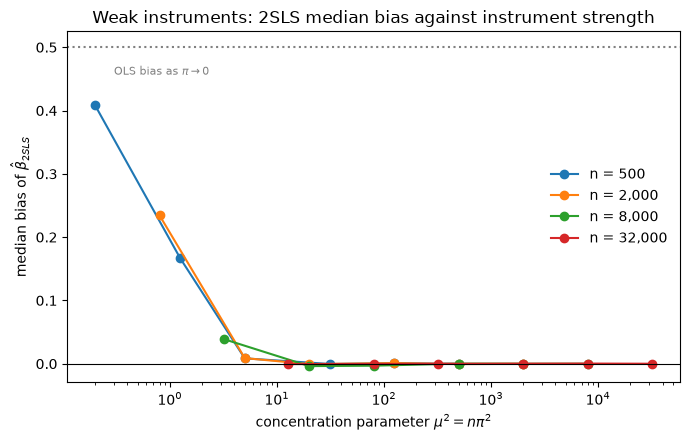

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
for n, g in summary.groupby("n"):
    g = g.sort_values("concentration_param")
    ax.plot(g["concentration_param"], g["median_bias_2sls"],
            marker="o", label=f"n = {n:,}")

ax.axhline(0.5, ls=":", color="grey")
ax.text(0.3, 0.47, r"OLS bias as $\pi \to 0$", fontsize=8, color="grey", va="top")
ax.axhline(0.0, lw=0.8, color="black")
ax.set_xscale("log")
ax.set_xlabel(r"concentration parameter $\mu^2 = n\pi^2$")
ax.set_ylabel(r"median bias of $\hat\beta_{2SLS}$")
ax.set_title("Weak instruments: 2SLS median bias against instrument strength")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

<font color = '701B1B'>**0. Conceptual**</font>

**Comment on what you see.** In particular:

1. What happens to the median bias of 2SLS as $\mu^2 \to 0$? What value does it
   approach, and why that value?
2. Look at `iqr_b_2sls` in the weak cells. What is happening to the dispersion of
   the estimator?
3. Look at `coverage_2sls`. Is the conventional 95% confidence interval
   under-covering or over-covering when the instrument is weak? Is that the answer
   you expected? What does it suggest about relying on coverage alone to detect a
   weak-instrument problem?

*Write your answers here.*

**Solution to 5.3.**

1. As $\mu^2 \to 0$ the median bias rises towards $+0.5$, which is $\rho/(\pi^2+1)$
   evaluated at $\pi \approx 0$ — the OLS inconsistency. With an irrelevant
   instrument, $z'x$ is pure noise and 2SLS carries no information about $\beta$;
   its distribution collapses onto the OLS probability limit.

2. The IQR explodes: roughly 1.6 at $\mu^2 \approx 0.2$ against 0.008 in the
   strongest cell, a factor of more than 200. Just-identified 2SLS is a ratio of two
   correlated normals; as the denominator's mean approaches zero the distribution
   develops Cauchy-like tails and has no finite moments. This is why we report
   *median* bias throughout: the mean bias is not a well-defined object to estimate
   here, and a "mean bias" column would be dominated by whichever replication got
   closest to dividing by zero.

3. Coverage stays close to nominal and in fact drifts slightly **above** 0.95
   (around 0.97–0.98 in the weakest cells) — the interval becomes conservative, not
   anti-conservative. This can be surprising but the reason is that the numerator and the denominator of the $t$-statistic blow up *together*, since
   the same near-zero $z'x$ that sends $\hat\beta$ far from $\beta$ also inflates
   the estimated standard error. The estimator is achieving the high coverage by returning intervals so wide they are uninformative.


## Part 6: Choosing a strategy

This part is mostly writing, not computing.


<font color = 'orange'>**2. AI Edit & Human Review**</font>

You have now run the same 24-cell grid three ways. Two of them you timed
directly; the third, a fully serial single-core run of the whole grid, you estimated
in Part 1.1 rather than running, because it is the slowest and least interesting use
of cluster time.

**6.1 — Assemble the comparison.**

*Run this cell here, in the notebook.* Uses `arr` and `cores` from Parts 4 and 3, plus the Part 1.1 estimate.

In [50]:
# `arr` and `cores` are the tables you built in Parts 4 and 3; `summary` is the table
# you downloaded in Part 5.
#
# For the serial row we do NOT use `est` from 1.1. That was measured on
# your laptop, and a laptop core is several times faster than a shared cluster core, so
# it is not comparable with the other two rows. `summary["elapsed_sec"]` is the compute
# time of each cell measured *on a cluster node*, so summing it gives a serial baseline
# on the same hardware.
serial_cluster_sec = summary["elapsed_sec"].sum()

rows = [
    {"strategy": "serial loop, 1 core (same node)",
     "queue_sec": float("nan"),
     "compute_sec": serial_cluster_sec,
     "total_sec": serial_cluster_sec,
     "cores_held": 1,
     # one core, held for the whole run
     "core_seconds": serial_cluster_sec},
    {"strategy": "one job, 4 cores (joblib)",
     "queue_sec": cores.QueueSec.iloc[0],
     "compute_sec": cores.RunSec.iloc[0],
     "total_sec": cores.QueueSec.iloc[0] + cores.RunSec.iloc[0],
     "cores_held": int(cores.AllocCPUS.iloc[0]),
     # a single job holds every core it was given for its whole run, idle or not
     "core_seconds": int(cores.AllocCPUS.iloc[0]) * cores.RunSec.iloc[0]},
    {"strategy": "job array, 24 x 1 core",
     "queue_sec": arr.QueueSec.median(),
     "compute_sec": arr.RunSec.max(),
     "total_sec": (arr.End.max() - arr.Submit.min()).total_seconds(),
     "cores_held": int(arr.AllocCPUS.sum()),
     # Slurm releases each task's core the moment that task ends, so an array is
     # charged the SUM of task runtimes - not 24 x the slowest one.
     "core_seconds": arr.RunSec.sum()},
]

comp = pd.DataFrame(rows)
print(comp.round(1).to_string(index=False))

print(f"\nYour laptop estimate from 1.1 was {est:.0f} s. It is deliberately not a row in")
print("the table, because it was measured on different hardware - but keep it in mind")
print("when you fill in the table.")
print("`total_sec` is what you care about as a researcher; `core_seconds` is what the")
print("cluster (and, on AWS, the budget) cares about.")


                       strategy  queue_sec  compute_sec  total_sec  cores_held  core_seconds
serial loop, 1 core (same node)        NaN        885.8      885.8           1         885.8
      one job, 4 cores (joblib)      185.0        303.0      488.0           4        1212.0
         job array, 24 x 1 core        1.0        146.0      366.0          24        1381.0

Your laptop estimate from 1.1 was 191 s. It is deliberately not a row in
the table, because it was measured on different hardware - but keep it in mind
for question 1.
`total_sec` is what you care about as a researcher; `core_seconds` is what the
cluster (and, on AWS, the budget) cares about.


<font color = '701B1B'>**0. Conceptual**</font>

**6.2 — The write-up.** Fill in the table below from your own numbers and experience using the scheduler.

We define "Queue risk" as how much of your total time-to-answer is at the mercy of the scheduler and the state of the cluster, rather than of your own code.

| Strategy | Total time to answer | Core-seconds consumed | Queue risk | Debugging difficulty | When would you pick it? |
|---|---|---|---|---|---|
| Serial loop, 1 core | | | | | |
| One job, 4 cores (`joblib`) | | | | | |
| Job array, 24 × 1 core | | | | | |


*Write your answers here.*

**Solution to 6.2.**

Numbers below are from the 60,000-replication run pasted into this notebook. Yours will
differ in detail; the pattern is what matters.

| Strategy | Total time to answer | Core-seconds consumed | Queue risk | Debugging difficulty | When would you pick it? |
|---|---|---|---|---|---|
| Serial loop, 1 core | **886 s** — compute only, since this row was never submitted and so pays no queue | **886** | Lowest: one job, the smallest request anyone can make, fits wherever a node exists | Easiest: one traceback, in order, and you can attach a debugger | As the baseline that makes the other two readable, and to debug at small scale before scaling out |
| One job, 4 cores (`joblib`) | **488 s** = 185 s queue + 303 s run | **1,212** | Low: one placement decision, but four cores must come free on one node at the same moment | Hardest: 24 cells interleaved in one log, `joblib` re-raises from a worker process, and you rerun the whole grid to reproduce | When the work does not split into independent pieces, or when one cell needs more memory than you want to give 24 tasks |
| Job array, 24 × 1 core | **366 s** | **1,381** | Highest: 24 placement decisions, and the makespan is set by the last task to get a core | Easiest at scale: one log per task, and `sbatch --array=19` reruns a single cell in seconds | The default for an embarrassingly parallel grid, once each task's work is large relative to the ~16 s it costs to start a task |


## Before you leave: clean up

Interactive apps and jobs hold cluster resources until they end, and on this
platform that costs real money. Check that you have nothing running, and cancel
anything you do not need.

*Copy this into the OnDemand terminal.* Check nothing of yours is still running. If something is and you do not need it, cancel it: `scancel <jobid>`, or `scancel -u $(whoami)` for everything.

```bash
squeue -u $(whoami)
```


# Submission ⭐

Congratulations, you finished the module. Please make sure your notebook contains:

- your completed `mc_one.sbatch`, `mc_big.sbatch`, `mc_cores.sbatch`,
  `mc_array.sbatch` and `aggregate.sbatch` (the `%%writefile` cells count),
- the `sacct` output for each part, and
- your written answers

We will handle all exercise submissions on GitHub Classroom. Please push your
changes to your team repository folder on GitHub Classroom. Do **not** commit
`results*/`, `logs/` or `.venv/`